In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import make_scorer, mean_absolute_error, root_mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

p22 = pd.read_csv('../data/processed_22.csv')
p23 = pd.read_csv('../data/processed_23.csv')
p24 = pd.read_csv('../data/processed_24.csv')
p25 = pd.read_csv('../data/processed_25.csv')
combined = pd.concat([p22, p23, p24, p25], ignore_index=True)

# top 20 features from paper + target variable
a = [
    "Lpoly_expected_ml", "Area", "Biovolume", "MajorAxisLength",
    "MinorAxisLength", "Perimeter", "Orientation", "Eccentricity",
    "Solidity", "texture_uniformity", "texture_smoothness",
    "texture_average_gray_level", "texture_entropy",
    "texture_average_contrast", "H90", "H180", "Hflip",
    "Extent", "EquivDiameter", "ConvexArea", "ConvexPerimeter",
    "Pmicans_expected_ml", # add another taxa as a predictor
]

foo = combined[a]

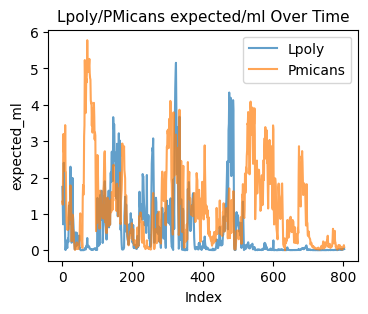

In [2]:
plt.figure(figsize=(4, 3))

y = combined['Lpoly_expected_ml'].copy()
y_log = np.log1p(y)
b = combined['Pmicans_expected_ml'].copy()
b_log = np.log1p(b)

plt.plot(y_log, label="Lpoly", alpha=0.7)
plt.plot(b_log, label="Pmicans", alpha=0.7)
plt.legend()

# combined['Lpoly_expected_ml'].plot(kind='line')
plt.title('Lpoly/PMicans expected/ml Over Time', fontsize=11)
plt.xlabel('Index')
plt.ylabel('expected_ml')

plt.show()

# log transformation seems good..
# think we're going to use normalized

In [3]:
s = combined[["date", "Lpoly_expected_ml"]].copy()
s["date"] = pd.to_datetime(s["date"].astype(str), format="%Y%m%d")
s = s.sort_values("date").set_index("date")
s = s.asfreq("D")

ema = s["Lpoly_expected_ml"].ewm(span=30, adjust=False).mean()
s.loc[s["Lpoly_expected_ml"].isna(), "Lpoly_expected_ml"] = ema

y = s["Lpoly_expected_ml"].values
y_norm = (y - np.mean(y)) / np.std(y)

##### Trivial model
- predict tomorrow = today
    - y_pred[t+1] = y[t]

Trivial RMSE: 0.70620149465385
Trivial Correlation: 0.7508356540233854


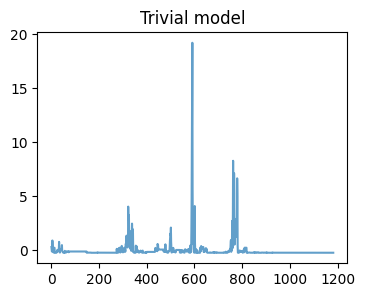

In [4]:
# tmrws value
y_true = y_norm[1:]
# predict todays value as tmrws value
y_pred = y_norm[:-1]

rmse = root_mean_squared_error(y_true, y_pred)
print("Trivial RMSE:", rmse)
correlation = np.corrcoef(y_true, y_pred)[0, 1]
print("Trivial Correlation:", correlation)

plt.figure(figsize=(4, 3))
plt.plot(y_pred, label="Predicted (trivial)", alpha=0.7)
plt.title("Trivial model")
plt.show()

##### Trivial Model 2
- Always predict the mean (.5/ml)

In [5]:
y_true = y_norm[1:]
mean_val = y_norm.mean()
y_pred = np.full(len(y_true), np.mean(y_norm,))
rmse = root_mean_squared_error(y_true, y_pred)
print("RMSE:", rmse)   
# correlation = np.corrcoef(y_true, y_pred)[0, 1]
print("Mean Correlation:", 0)

# means nothing since normalized lol

RMSE: 1.0003881506697654
Mean Correlation: 0


##### Ridge Regression 1 day lag

In [13]:
# normalize features and fill missing values with EMA
df = combined[["date"] + a].copy()
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d")
df = df.sort_values("date").set_index("date")
df = df.asfreq("D")

df_filled = df.copy()

for col in a:
    ema = df[col].ewm(span=30, adjust=False).mean()
    df_filled[col] = df[col].fillna(ema)

# normalize features
df_norm = df_filled.copy()
for col in a:
    mu = df_filled[col].mean()
    sigma = df_filled[col].std()
    df_norm[col] = (df_filled[col] - mu) / sigma

In [21]:
# ridge regression of 21 features normalized
y = df_norm["Lpoly_expected_ml"].values
X = df_norm.drop(columns=["Lpoly_expected_ml" ])

X = X.iloc[:-1].reset_index(drop=True)
y = y[1:]

ridge = Ridge(alpha=1.0)
ridge.fit(X, y)

y_pred = ridge.predict(X)

rmse = root_mean_squared_error(y, y_pred)
corr = np.corrcoef(y, y_pred)[0, 1]

print("Ridge RMSE:", rmse)
print("Ridge Correlation:", corr)

Ridge RMSE: 0.9333862916707064
Ridge Correlation: 0.35896752538200044


In [16]:
# looking at missing data
# missing data not great for time series analysis, but we can at least identify the gaps
w = pd.to_datetime(
    combined['date'].astype(str),
    format='%Y%m%d'
)

full_dates = pd.date_range(
    start=w.min(),
    end=w.max(),
    freq='D'
)
observed_dates = w
missing_dates = full_dates.difference(observed_dates)

print("Total days in range:", len(full_dates))
print("Total days with data:", len(observed_dates))
print("Days with true missing data:", len(missing_dates))

missing_df = pd.DataFrame({'date': missing_dates})
missing_df['year_month'] = missing_df['date'].dt.to_period('M')
# missing_df['year_month'].value_counts().sort_index()

Total days in range: 1184
Total days with data: 805
Days with true missing data: 379


##### random forest with 7 days lag and 21 features

cross validation using timeseries split
- it basically chunks train/test split

In [24]:
y = df_norm["Lpoly_expected_ml"]
X = df_norm.drop(columns=["Lpoly_expected_ml" ])

lag = 7
X_lag = X.iloc[:-lag].reset_index(drop=True)
y_lag = y.iloc[lag:].reset_index(drop=True)

scoring = {
    "mae": make_scorer(mean_absolute_error, greater_is_better=False),
    "rmse": make_scorer(root_mean_squared_error, greater_is_better=False),
    "r2": make_scorer(r2_score)
}

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    random_state=67,
    n_jobs=-1
)

tscv = TimeSeriesSplit(n_splits=10)

cv_results = cross_validate(
    rf,
    X_lag,
    y_lag,
    cv=tscv,
    scoring=scoring,
    return_train_score=False
)

print("RMSE:", -cv_results["test_rmse"].mean(), "+/-", cv_results["test_rmse"].std())
print("MAE: ", -cv_results["test_mae"].mean(), "+/-", cv_results["test_mae"].std())
print("R2:",  cv_results["test_r2"].mean(), "+/-", cv_results["test_r2"].std())

RMSE: 0.7820668660129201 +/- 0.7443005868331426
MAE:  0.3280890329448049 +/- 0.23969384406444338
R2: -5088.798485996823 +/- 9967.478378868458
